# Quality Assessment

In [1]:
import pandas as pd

# Load data into pandas DataFrames
path = 'cleaned_csv/'
brands = pd.read_csv(path+'brands_cl.csv')
orderlines = pd.read_csv(path+'orderlines_cl.csv')
orders = pd.read_csv(path+'orders_cl.csv')
products = pd.read_csv(path+'products_cl.csv')

path2 = 'original_csv/'
brands_orig = pd.read_csv(path2+'brands.csv')
orderlines_orig = pd.read_csv(path2+'orderlines.csv')
orders_orig = pd.read_csv(path2+'orders.csv')
products_orig = pd.read_csv(path2+'products.csv')

Load cleaned DataFrames

In [2]:
# create copies of the original data
orders_df = orders.copy()
orderlines_df = orderlines.copy()
brands_df = brands.copy()
products_df = products.copy()

## 1.&nbsp; Define Pandas display format

In [3]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 1000)

## 2.&nbsp; Exclude unwanted orders

In [4]:
#order states
orders_df.groupby('state')['order_id'].count()

state
Cancelled            7233
Completed           46605
Pending             14374
Place Order         40883
Shopping Basket    117809
Name: order_id, dtype: int64

In [5]:
# orders –> Keep only orders with the state 'Completed'
completed_mask = orders_df['state'] == 'Completed'
orders_df = orders_df[completed_mask]


In [6]:
# orderlines –> Keep only orders present in orders
id_order_mask = orderlines_df['id_order'].isin(orders_df['order_id'])
orderlines_df = orderlines_df[id_order_mask]
orderlines_df.shape

(56714, 6)

In [7]:
# orders –> Keep only orders present in orderlines
order_id_mask = orders_df['order_id'].isin(orderlines_df['id_order'])
orders_df = orders_df[order_id_mask]
orders_df.shape

(43064, 4)

In [8]:
orders_df["order_id"].nunique(), orderlines_df["id_order"].nunique()

(43064, 43064)

## 3.&nbsp; Exclude orders with unknown products


In [9]:
# join orderlines with products to see which orderlines are not associated with an order (name field will be NaN)
orderlines_products = orderlines_df.merge(products_df, how="left", on = "sku")[["id_order","sku","name" ]]
orderlines_products.sample(10)

,id_order,sku,name
49957,499327,WDT0406,WD My Cloud Home 6TB USB 3.0
12311,354504,FCM0022,FCM Mac Memory 4GB DDR3 1333MHz SO-DIMM
3014,309006,SPH0016,Sphero BB-8 Battle-Worn Force Band Bracelet + ...
13703,360588,NOM0024,Nomad Horween Leather Strap Leather strap brow...
23316,396455,APP0698,Apple Lightning Cable Connector to USB 1m Whit...
53627,513740,WDT0343,"WD Red Pro 6TB 35 ""Sata 3 7200RPM"
2052,306272,LEX0015,Lexar High-Performance Memory Card MicroSDHC U...
4200,312225,APP0698,Apple Lightning Cable Connector to USB 1m Whit...
26825,411322,BEL0133,Belkin MIXIT Silver Lightning iPhone Support
1649,305186,GRT0446,Griffin Survivor iPhone Case Journey 8 Plus / ...


In [10]:
# count missing products
orderlines_products['name'].isna().value_counts()

name
False    55320
True      1394
Name: count, dtype: int64

In [11]:
# step 1: define orders to delete
orders_to_delete = orderlines_products.loc[orderlines_products['name'].isna(), "id_order"].unique()

# step 2: keep only orders that are not in corrupted list
orders_df = orders_df.loc[~orders_df.order_id.isin(orders_to_delete),:]

# step 3: keep only orderlines that are not in corrupted list of orders
orderlines_df = orderlines_df.loc[~orderlines_df.id_order.isin(orders_to_delete),:]

In [12]:
orders_df["order_id"].nunique(), orderlines_df["id_order"].nunique()

(41701, 41701)

In [13]:
products_df.shape

(9992, 6)

In [14]:
orderlines_df.shape

(54324, 6)

In [15]:
orders_df.shape

(41701, 4)

## 4.&nbsp; Explore the revenue from different tables

In [ ]:
# Create the `unit_price_total` as `orderlines.unit_price` * `orderlines.product_quantity`
orderlines_df.loc[:,'unit_price_total'] = orderlines_df['unit_price'] * orderlines_df['product_quantity']
orderlines_df

,id,id_order,product_quantity,sku,unit_price,date,unit_price_total
6,1119116,299545,1,OWC0100,47.49,2017-01-01 01:46:16,47.49
7,1119119,299546,1,IOT0014,18.99,2017-01-01 01:50:34,18.99
8,1119120,295347,1,APP0700,72.19,2017-01-01 01:54:11,72.19
15,1119134,299556,1,CRU0039-A,60.90,2017-01-01 02:20:14,60.90
21,1119145,299561,1,PEB0015,142.49,2017-01-01 02:38:50,142.49
...,...,...,...,...,...,...,...
215889,1649474,525664,1,TUC0207,16.52,2018-03-14 11:45:05,16.52
215906,1649512,527070,2,APP0698,9.99,2018-03-14 11:49:01,19.98
215911,1649522,527074,2,APP0698,9.99,2018-03-14 11:49:36,19.98
215932,1649565,527096,3,APP0698,9.99,2018-03-14 11:54:35,29.97


In [ ]:
# Group by `id_order`, summarising by the sum of `unit_price_total`
# Group
unit_price_total_series = orderlines_df.groupby('id_order', as_index=False)['unit_price_total'].sum()

# merge with orders
orders_merged = orders_df.merge(unit_price_total_series, left_on = 'order_id', right_on = 'id_order', how = 'left')
orders_merged


,order_id,created_date,total_paid,state,id_order,unit_price_total
0,241423,2017-11-06 13:10:02,136.15,Completed,241423,129.16
1,242832,2017-12-31 17:40:03,15.76,Completed,242832,10.77
2,243330,2017-02-16 10:59:38,84.98,Completed,243330,77.99
3,245275,2017-06-28 11:35:37,149.00,Completed,245275,149.00
4,245595,2017-01-21 12:52:47,112.97,Completed,245595,105.98
...,...,...,...,...,...,...
41696,527042,2018-03-14 11:47:50,18.98,Completed,527042,13.99
41697,527070,2018-03-14 11:50:48,24.97,Completed,527070,19.98
41698,527074,2018-03-14 11:51:42,24.97,Completed,527074,19.98
41699,527096,2018-03-14 11:58:40,34.96,Completed,527096,29.97


### Explore the average difference between `total_paid` and `unit_price_total`

In [18]:
# create new column with difference between total_paid and unit_price_total
orders_merged.loc[:,'diff_total_paid_unit_price_total'] = orders_merged['total_paid'] - orders_merged['unit_price_total']
orders_merged['diff_total_paid_unit_price_total'].describe()

count   41701.00
mean        4.47
std        26.05
min      -165.00
25%         0.00
50%         4.99
75%         6.99
max      3984.99
Name: diff_total_paid_unit_price_total, dtype: float64

In [19]:
orders_merged['diff_total_paid_unit_price_total'].median()

np.float64(4.989999999999995)

### What is the distribution of these differences?

<Axes: >

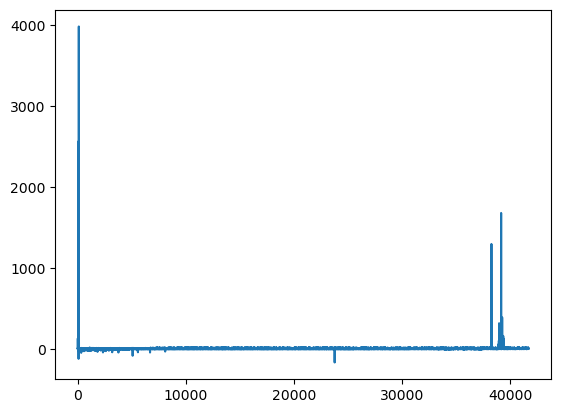

In [ ]:
# normal plot
orders_merged['diff_total_paid_unit_price_total'].plot()

<Axes: >

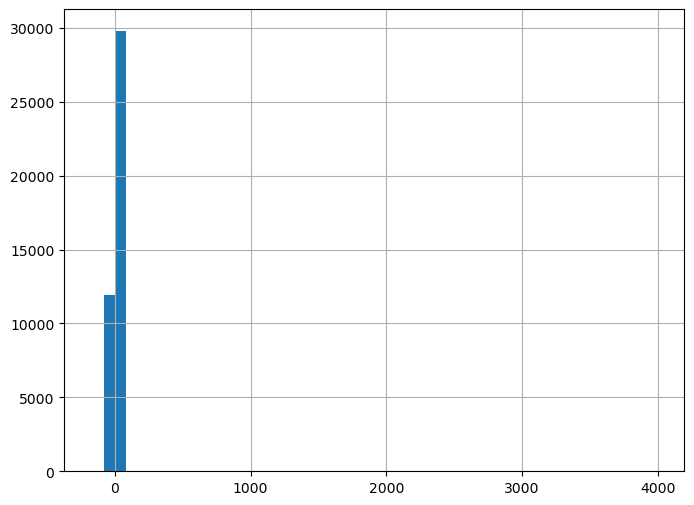

In [ ]:
# histogram
orders_merged['diff_total_paid_unit_price_total'].hist(bins= 50, figsize=(8,6))

If they are below 0, they could be explained by someone cashing in a gift card

There's a rule of thumb, that anything:
+ lower than the 25% quartile - (1.5 x interquartile range), or
+ higher than the 75% quartile + (1.5 x interquartile range)

is an outlier. Let's use this rule to try and exclude any corrupted data.

In [22]:
# calculate the quartiles
Q1 = orders_merged['diff_total_paid_unit_price_total'].quantile(0.25)
Q3 = orders_merged['diff_total_paid_unit_price_total'].quantile(0.75)

Q1, Q3

(np.float64(0.0), np.float64(6.989999999999981))

In [23]:
# calculate the interquartile range
IQR = Q3-Q1
IQR

np.float64(6.989999999999981)

In [33]:
Q1 - 1.5*IQR

np.float64(-10.484999999999971)

In [34]:
Q3 + 1.5*IQR

np.float64(17.47499999999995)

In [24]:
# filter the DataFrame to include only "non-outliers"
orders_merged_no_outliers_df = orders_merged.loc[
    (orders_merged['diff_total_paid_unit_price_total'] >= (Q1 - 1.5*IQR))
    &
    (orders_merged['diff_total_paid_unit_price_total'] <= (Q3 + 1.5*IQR))
    ,
    :]

<Axes: >

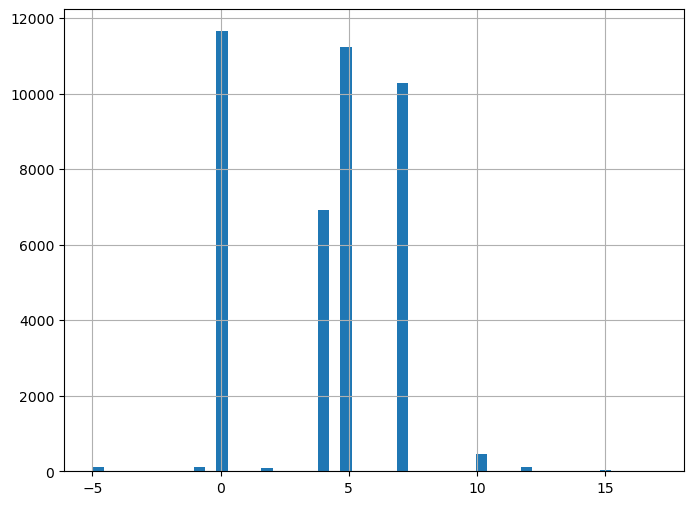

In [ ]:
orders_merged_no_outliers_df['diff_total_paid_unit_price_total'].hist(bins= 50, figsize=(8,6))

This looks much more like what we would expect: a small difference, but nothing extreme.

Now these orders with extreme differences need to be removed from the orders_merged DataFrame.

In [26]:
# create series that contains order_ids from the no outlier merged df
normal_diff_list = orders_merged_no_outliers_df["order_id"]

# keep only orders that are in the no outlier merged df
orders_df = orders_df.loc[orders_df["order_id"].isin(normal_diff_list), :]

# keep only orderlines that are in the no outlier merged df
orderlines_df = orderlines_df.loc[orderlines_df["id_order"].isin(normal_diff_list), :]

orders_df["order_id"].nunique(), orderlines_df["id_order"].nunique()

(40985, 40985)

### Compare the orderlines.unit_price with products.price

In [27]:

orderlines_product_merge = orderlines_df.merge(products_df, on='sku', how = 'left')

orderlines_product_merge.loc[:,'diff_unit_price_price'] = orderlines_product_merge['price'] - orderlines_product_merge['unit_price']

diff_unit_price_price_series = orderlines_product_merge.groupby('sku')['diff_unit_price_price'].mean()
products_merge = products_df.merge(diff_unit_price_price_series, on='sku', how='inner')


In [28]:
products_merge['diff_unit_price_price'].describe()


count   5098.00
mean      36.25
std       84.42
min     -130.00
25%        5.45
50%       13.83
75%       33.94
max     1320.00
Name: diff_unit_price_price, dtype: float64

<Axes: >

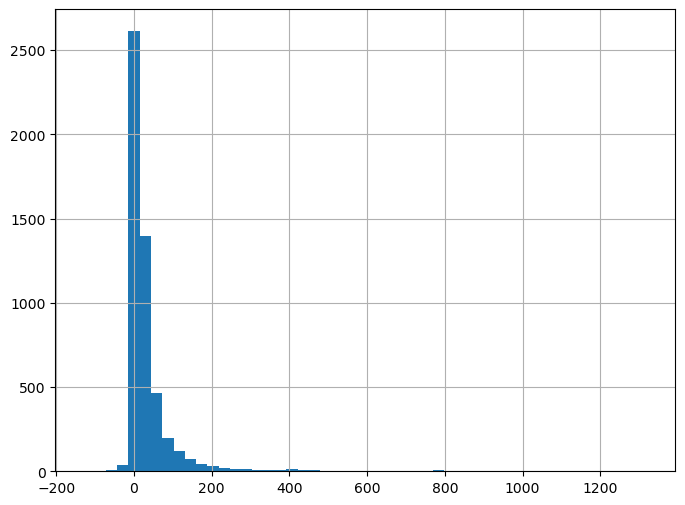

In [ ]:
# histogram
products_merge['diff_unit_price_price'].hist(bins= 50, figsize=(8,6))

This looks mostly fine

Check data frames before saving

In [46]:
orders_df.info()

<class 'pandas.DataFrame'>
Index: 40985 entries, 1 to 226614
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      40985 non-null  int64  
 1   created_date  40985 non-null  str    
 2   total_paid    40985 non-null  float64
 3   state         40985 non-null  str    
dtypes: float64(1), int64(1), str(2)
memory usage: 1.6 MB


In [47]:
orderlines_df.info()

<class 'pandas.DataFrame'>
Index: 53231 entries, 6 to 215949
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                53231 non-null  int64  
 1   id_order          53231 non-null  int64  
 2   product_quantity  53231 non-null  int64  
 3   sku               53231 non-null  str    
 4   unit_price        53231 non-null  float64
 5   date              53231 non-null  str    
 6   unit_price_total  53231 non-null  float64
dtypes: float64(2), int64(3), str(2)
memory usage: 3.2 MB


In [48]:
products_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9992 entries, 0 to 9991
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sku       9992 non-null   str    
 1   name      9992 non-null   str    
 2   desc      9992 non-null   str    
 3   price     9992 non-null   float64
 4   in_stock  9992 non-null   int64  
 5   type      9946 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 468.5 KB


In [49]:
brands_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   short   187 non-null    str  
 1   long    187 non-null    str  
dtypes: str(2)
memory usage: 3.1 KB


Save dataframes

In [31]:
save_path = 'quality_assured_csv/'
orders_df.to_csv(save_path+'orders_qu.csv', index=False)
orderlines_df.to_csv(save_path+'orderlines_qu.csv', index=False)
products_df.to_csv(save_path+'products_qu.csv', index=False)
brands_df.to_csv(save_path+'brands_qu.csv', index=False)

Additional function for outlier cleaning for the future

In [ ]:
# function that takes in a data frame and the name of a numerical column and returns a mask that could be used to select outlier rows

def outliers_filter(df, num_col):
    q1 = df[num_col].quantile(0.25)
    q3 = df[num_col].quantile(0.75)
    iqr = q3-q1
    outlier_mask = (df[num_col] >= (q1 - 1.5*iqr)) & (df[num_col] <= (q3 + 1.5*iqr))
    return outlier_mask